In [25]:
import logging
import os

logging.basicConfig(
    format='%(asctime)s - %(levelname)s - %(name)s: %(message)s',
    level=logging.INFO,
)
logger = logging.getLogger('finetune.ipynb')

DATA_FOLDER = os.path.join(os.path.expanduser('~'), 'data', 'ds000030')
PREPROCESSED_IMAGES_FOLDER = os.path.join(DATA_FOLDER, 'preprocessed')
LABELS_PATH = os.path.join(DATA_FOLDER, 'labels.csv')
LABELS = ['CONTROL', 'ADHD', 'BIPOLAR', 'SCHZ']

BATCH_SIZE = 3
NUM_THREADS = 3

2026-06-08 21:43:14,127 - INFO - pyment.data.dataset: Computed balanced class weights: {'ADHD': np.float64(1.6158536585365855), 'BIPOLAR': np.float64(1.3520408163265305), 'CONTROL': np.float64(0.53), 'SCHZ': np.float64(1.325)}
100%|█████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 245091.63it/s]
2026-06-08 21:43:14,324 - INFO - finetune.ipynb: Training on 212 samples
2026-06-08 21:43:14,324 - INFO - finetune.ipynb: Validating on 53 samples


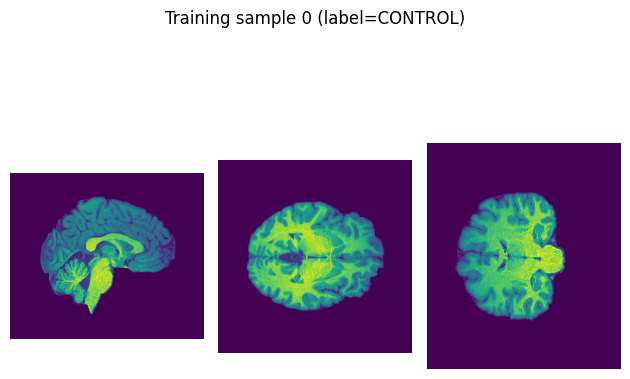

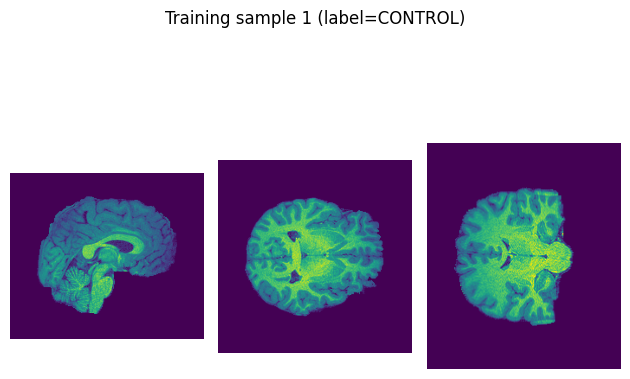

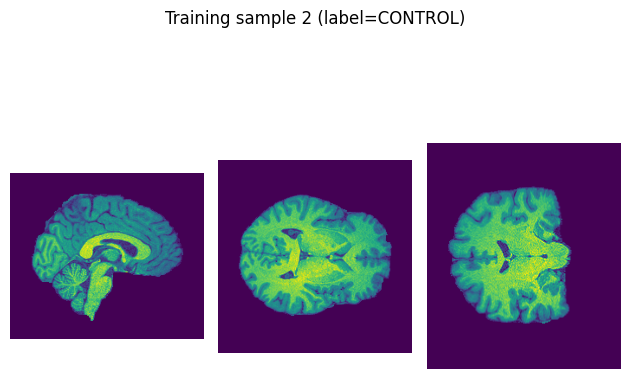

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from pyment.data import FastSurferDataset


# Manual onehot encoding
def target_encoder(value):
    return LABELS.index(value)


dataset = FastSurferDataset.from_paths(
    images_path=PREPROCESSED_IMAGES_FOLDER,
    labels_path=LABELS_PATH,
    target='diagnosis',
    target_encoder=target_encoder,
    class_weights='balanced',
)
train, validation = dataset.random_split(training_fraction=0.8)

train_generator = train.to_tensorflow_generator(
    batch_size=BATCH_SIZE, num_threads=NUM_THREADS, shuffle=True
)
validation_generator = validation.to_tensorflow_generator(
    batch_size=BATCH_SIZE, num_threads=NUM_THREADS, shuffle=False
)

logger.info('Training on %d samples', len(train))
logger.info('Validating on %d samples', len(validation))

for name, generator in [
    ('Training', train_generator),
    ('Validation', validation_generator),
]:
    for X, y in generator:
        for i in range(BATCH_SIZE):
            image = X[i].numpy()
            fig, ax = plt.subplots(1, 3)

            for dim in range(3):
                ax[dim].imshow(
                    np.take(image, indices=image.shape[dim] // 2, axis=dim)
                )
                ax[dim].axis('off')

            label = LABELS[np.argmax(y[i].numpy())]
            fig.suptitle(f'Training sample {i} (label={label})')

            plt.tight_layout()
            plt.show()
        break

array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.]], shape=(265, 4))